In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("iris.csv", header=None)

df.head()

,0,1,2,3,4
0,150.0,4.0,setosa,versicolor,virginica
1,5.1,3.5,1.4,0.2,0
2,4.9,3.0,1.4,0.2,0
3,4.7,3.2,1.3,0.2,0
4,4.6,3.1,1.5,0.2,0


In [3]:
# Remove the metadata row
df = df.iloc[1:].reset_index(drop=True)

# Assign proper column names
df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nTarget Classes:")
print(df["species"].value_counts())

Dataset Shape: (150, 5)

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Data Types:
sepal_length    float64
sepal_width     float64
petal_length        str
petal_width         str
species             str
dtype: object

Target Classes:
species
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
# Separate features and target
X = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]]

y = df["species"]

# Convert target labels to numeric classes
y = y.astype(int)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the input features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [6]:
# Build the neural network
model = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

# Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

C:\Users\Saksh\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train the neural network
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.5417 - loss: 0.9255 - val_accuracy: 0.4167 - val_loss: 0.9852
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5833 - loss: 0.9009 - val_accuracy: 0.4583 - val_loss: 0.9644
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5938 - loss: 0.8788 - val_accuracy: 0.5000 - val_loss: 0.9439
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6042 - loss: 0.8584 - val_accuracy: 0.5000 - val_loss: 0.9246
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6458 - loss: 0.8374 - val_accuracy: 0.5000 - val_loss: 0.9049
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6667 - loss: 0.8179 - val_accuracy: 0.5417 - val_loss: 0.8858
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6667 - loss: 0.7989 - val_accuracy: 0.6250 - val_loss: 0.8659
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6875 - loss: 0.7807 - val_accuracy: 0.6250 - val_loss: 0.8461


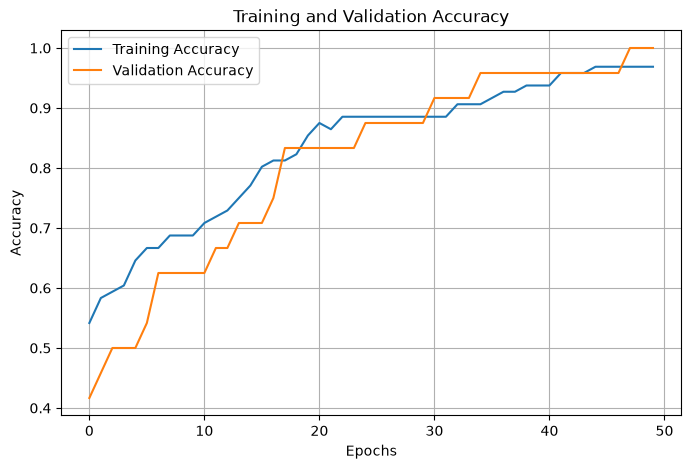

In [8]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

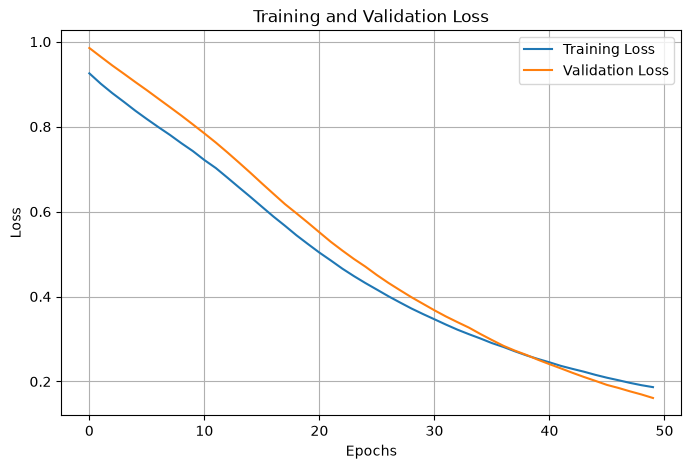

In [9]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [10]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Test Accuracy (%):", round(test_accuracy * 100, 2), "%")

Test Loss: 0.2132
Test Accuracy: 0.9667
Test Accuracy (%): 96.67 %


In [11]:
# Generate predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [12]:
# Build a tuned neural network
tuned_model = Sequential([
    Dense(16, activation="relu", input_shape=(4,)),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

# Use a different learning rate
tuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train with a smaller batch size
tuned_history = tuned_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50


C:\Users\Saksh\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.2708 - loss: 1.1935 - val_accuracy: 0.4167 - val_loss: 1.0363
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4792 - loss: 0.9800 - val_accuracy: 0.7083 - val_loss: 0.8604
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6354 - loss: 0.8177 - val_accuracy: 0.6250 - val_loss: 0.7079
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6875 - loss: 0.6657 - val_accuracy: 0.7083 - val_loss: 0.5923
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7708 - loss: 0.5435 - val_accuracy: 0.6667 - val_loss: 0.5263
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7812 - loss: 0.4785 - val_accuracy: 0.6250 - val_loss: 0.4963
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7917 - loss: 0.4311 - val_accuracy: 0.6667 - val_loss: 0.4636
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8333 - loss: 0.3927 - val_accuracy: 0.7500 - val_loss: 0.

In [13]:
# Evaluate the tuned model on the test dataset
tuned_test_loss, tuned_test_accuracy = tuned_model.evaluate(
    X_test, y_test, verbose=0
)

print("Tuned Test Loss:", round(tuned_test_loss, 4))
print("Tuned Test Accuracy:", round(tuned_test_accuracy, 4))
print("Tuned Test Accuracy (%):", round(tuned_test_accuracy * 100, 2), "%")

Tuned Test Loss: 0.0806
Tuned Test Accuracy: 0.9667
Tuned Test Accuracy (%): 96.67 %


In [14]:
# Compare Original and Tuned Models

print("MODEL COMPARISON")
print("-" * 40)

print("Original Model Test Accuracy:",
      round(test_accuracy * 100, 2), "%")

print("Tuned Model Test Accuracy:",
      round(tuned_test_accuracy * 100, 2), "%")

print("Original Model Test Loss:",
      round(test_loss, 4))

print("Tuned Model Test Loss:",
      round(tuned_test_loss, 4))

MODEL COMPARISON
----------------------------------------
Original Model Test Accuracy: 96.67 %
Tuned Model Test Accuracy: 96.67 %
Original Model Test Loss: 0.2132
Tuned Model Test Loss: 0.0806


In [15]:
# Classification Report for Tuned Model

y_pred_prob = tuned_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Tuned Model Classification Report:")
print(classification_report(y_test, y_pred))

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



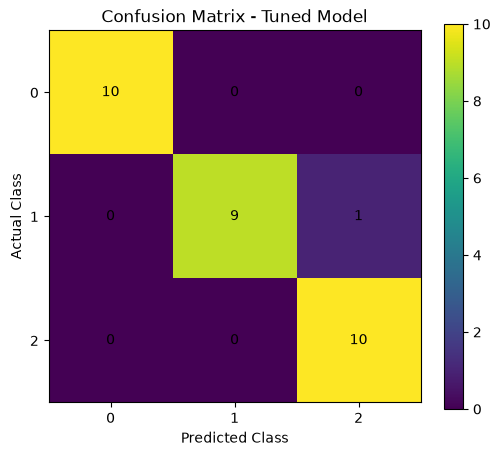

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Tuned Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0, 1, 2])
plt.yticks([0, 1, 2])
plt.show()

In [19]:
# Example Predictions

sample_predictions = y_pred[:10]
sample_actual = y_test.to_numpy()[:10]

print("Actual Classes:   ", sample_actual)
print("Predicted Classes:", sample_predictions)

Actual Classes:    [0 2 1 1 0 1 0 0 2 1]
Predicted Classes: [0 2 1 1 0 1 0 0 2 1]


In [ ]:
## Conclusion

A feed-forward neural network was developed using TensorFlow/Keras
to classify the Iris dataset.

The dataset was preprocessed by separating features and target,
splitting the data into training and testing sets, and standardizing
the input features.

The original model achieved a test accuracy of 96.67%.
After hyperparameter tuning using a smaller batch size and a
different learning rate, the tuned model achieved the same test
accuracy of 96.67%, while reducing the test loss from 0.2132 to 0.0806.

The confusion matrix and classification report show that the model
performed well across all three classes.

Overall, the neural network successfully classified the Iris dataset
with high accuracy and demonstrated improved loss after tuning.